Використай цей шаблон в роботі з датасетом.    
Ти можеш додавати комірки за потреби, але не змінюй структуру і послідовність питань.    
Обмежся функціями з наведених бібліотек.

In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Переглянь список .json файлів, доступних за адресою https://github.com/prust/wikipedia-movie-data/tree/master.    
Відкрий будь-який файл, що містить у своїй назві рік і ознайомся з його структурою.    
Тепер сформуй список файлів, які ти будеш завантажувати.    
Для формування послідовності слід використати функцію numpy.arange.    
Довжина послідовності має становити не менше 5 датасетів(наприклад з 1960 по 2000  рік включно).    
Повну адресу сформуй через конкатенацію рядків.

In [5]:
base_url = "https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies-"

years = np.arange(1970, 2020, 10)

file_urls = [base_url + str(year) + "s.json" for year in years]

file_urls

['https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies-1970s.json',
 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies-1980s.json',
 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies-1990s.json',
 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies-2000s.json',
 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies-2010s.json']

2. Тепер послідовність дій наступна.   
Слід пройти по всім обраним тобою файлам, прочитати кожен, як json об'єкт.        
Позбутись зайвих стовпців: ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height'].     
Залишити лише повні рядки(рядки без пропущених значень).     
Об'єднати інформацію з усіх файлів в єдиний датасет.

In [6]:
dfs = []

for url in file_urls:
    df = pd.read_json(url)

    # прибираємо зайві колонки, якщо вони є
    df = df.drop(
        columns=['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height'],
        errors='ignore'
    )

    # залишаємо тільки повні рядки
    df = df.dropna()

    dfs.append(df)

# об'єднуємо всі датасети в один
movies_df = pd.concat(dfs, ignore_index=True)

movies_df.head()

,title,year,cast,genres
0,A.k.a. Cassius Clay,1970,[Muhammad Ali],"[Documentary, Sports]"
1,Adam at Six A.M.,1970,"[Michael Douglas, Lee Purcell, Joe Don Baker, ...",[Drama]
2,Adam's Woman,1970,"[Beau Bridges, Jane Merrow, John Mills, James ...","[Historical, Drama]"
3,The Adventurers,1970,"[Bekim Fehmiu, Candice Bergen, Charles Aznavou...","[Drama, Adventure]"
4,Airport,1970,"[Burt Lancaster, Dean Martin, Jean Seberg, Jac...","[Disaster, Drama]"


3. Перевір розмір фінального датасету. Він має включати 4(чотири) стовпчика. Кількість рядків залежить від обраної кількості файлів. Збережи собі копію у вигляді csv або json файлу. Це убезпечить тебе від форс-мажорів.

In [7]:
movies_df.shape


(11680, 4)

In [11]:
movies_df.to_csv("movies_cleaned.csv", index=False)


In [12]:
movies_df.to_json("movies_cleaned.json", orient="records", lines=True)


4. Для json файлу не варто використовувати метод describe. Файл містить вкладені структури.    
Перевір вміст перших рядочків і використай метод info.

In [13]:
movies_df.head()
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11680 entries, 0 to 11679
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   11680 non-null  object
 1   year    11680 non-null  int64 
 2   cast    11680 non-null  object
 3   genres  11680 non-null  object
dtypes: int64(1), object(3)
memory usage: 365.1+ KB


5. Тепер слід попрацювати з жанрами.    
Віднайди топ 10 жанрів за кількістю фільмів.    
Побудуй стовпчикову та кругову діаграму, а також виведи на екран підсумкову таблицю.

In [14]:
genres_df = movies_df.explode('genres')


In [16]:
top_genres = (
    genres_df['genres']
    .value_counts()
    .head(10)
    .reset_index()
)

top_genres.columns = ['genre', 'movie_count']
top_genres


,genre,movie_count
0,Comedy,4096
1,Drama,4030
2,Action,1582
3,Thriller,1414
4,Horror,1205
5,Romance,1080
6,Crime,869
7,Science Fiction,784
8,Adventure,563
9,Fantasy,556


[Text(0, 0, 'Comedy'),
 Text(1, 0, 'Drama'),
 Text(2, 0, 'Action'),
 Text(3, 0, 'Thriller'),
 Text(4, 0, 'Horror'),
 Text(5, 0, 'Romance'),
 Text(6, 0, 'Crime'),
 Text(7, 0, 'Science Fiction'),
 Text(8, 0, 'Adventure'),
 Text(9, 0, 'Fantasy')]

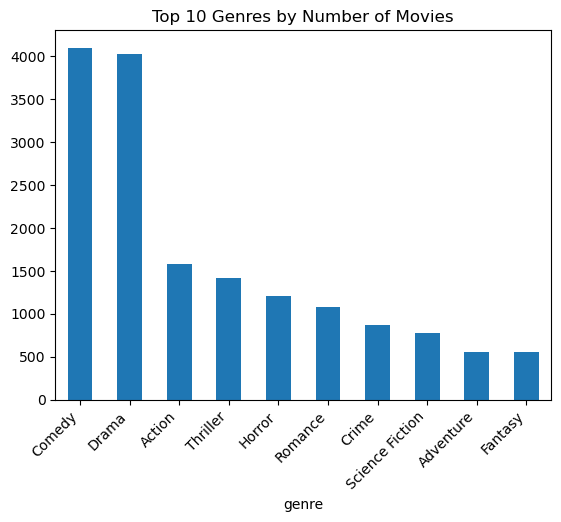

In [20]:
ax = top_genres.plot(
    x='genre',
    y='movie_count',
    kind='bar',
    legend=False,
    title='Top 10 Genres by Number of Movies'
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


<Axes: title={'center': 'Top 10 Genres Share'}, ylabel='movie_count'>

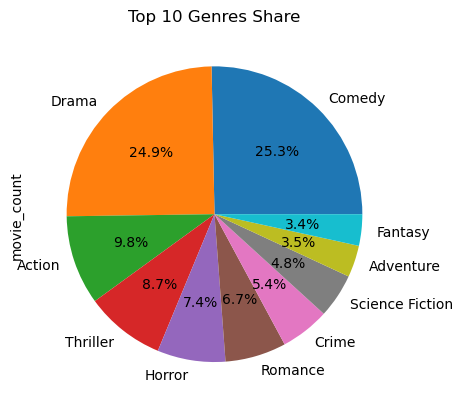

In [18]:
top_genres.set_index('genre').plot(
    y='movie_count',
    kind='pie',
    autopct='%1.1f%%',
    legend=False,
    title='Top 10 Genres Share'
)


6. Тепер вибери 3 найпопулярніших жанри і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.     
Для цього підрахуй кількість фільмів в кожному жанрі за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

In [27]:
##Вибір топ-3 жанрів
top_3_genres = top_genres['genre'].head(3).tolist()
top_3_genres


['Comedy', 'Drama', 'Action']

In [31]:
##Розгортання жанрів і фільтрація
genres_year_df = (
    movies_df
    .explode('genres')
    .query('genres in @top_3_genres')
)
genres_year_df

,title,year,cast,genres
1,Adam at Six A.M.,1970,"[Michael Douglas, Lee Purcell, Joe Don Baker, ...",Drama
2,Adam's Woman,1970,"[Beau Bridges, Jane Merrow, John Mills, James ...",Drama
3,The Adventurers,1970,"[Bekim Fehmiu, Candice Bergen, Charles Aznavou...",Drama
4,Airport,1970,"[Burt Lancaster, Dean Martin, Jean Seberg, Jac...",Drama
5,Alex in Wonderland,1970,"[Donald Sutherland, Ellen Burstyn, Federico Fe...",Comedy
...,...,...,...,...
11671,A Hidden Life,2019,"[August Diehl, Valerie Pachner, Matthias Schoe...",Drama
11675,Spies in Disguise,2019,"[Will Smith, Tom Holland, Rashida Jones, Ben M...",Comedy
11676,Little Women,2019,"[Saoirse Ronan, Emma Watson, Florence Pugh, El...",Drama
11678,Just Mercy,2019,"[Michael B. Jordan, Jamie Foxx, Brie Larson, R...",Drama


In [32]:
##Підрахунок фільмів за рік і жанр
genre_year_counts = (
    genres_year_df
    .groupby(['year', 'genres'])
    .size()
    .reset_index(name='movie_count')
)
genre_year_counts


,year,genres,movie_count
0,1970,Action,8
1,1970,Comedy,55
2,1970,Drama,70
3,1971,Action,15
4,1971,Comedy,40
...,...,...,...
145,2018,Comedy,74
146,2018,Drama,101
147,2019,Action,30
148,2019,Comedy,75


Text(0.5, 0, 'Year')

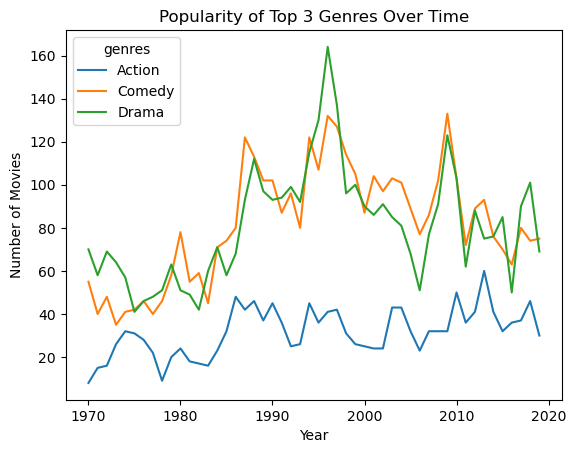

In [33]:
ax = genre_year_counts.pivot(
    index='year',
    columns='genres',
    values='movie_count'
).plot(
    kind='line',
    title='Popularity of Top 3 Genres Over Time'
)

ax.set_ylabel('Number of Movies')
ax.set_xlabel('Year')


7. Тепер слід попрацювати з акторами.     
Віднайди топ 10 акторів за кількістю фільмів.    
Побудуй стовпчикову або кругову діаграму, а також виведи на екран підсумукову таблицю.

In [35]:
##Розгортання акторів
actors_df = movies_df.explode('cast')
actors_df

,title,year,cast,genres
0,A.k.a. Cassius Clay,1970,Muhammad Ali,"[Documentary, Sports]"
1,Adam at Six A.M.,1970,Michael Douglas,[Drama]
1,Adam at Six A.M.,1970,Lee Purcell,[Drama]
1,Adam at Six A.M.,1970,Joe Don Baker,[Drama]
1,Adam at Six A.M.,1970,Louise Latham,[Drama]
...,...,...,...,...
11679,Clemency,2019,Alfre Woodard,[Drama]
11679,Clemency,2019,Wendell Pierce,[Drama]
11679,Clemency,2019,Aldis Hodge,[Drama]
11679,Clemency,2019,Richard Schiff,[Drama]


In [53]:
##Top-10 акторів
top_actors = (
    actors_df['cast']
    .value_counts()
    .head(10)
    .reset_index()
)

top_actors.columns = ['actor', 'movie_count']
top_actors


,actor,movie_count
0,Samuel L. Jackson,87
1,Robert De Niro,84
2,Bruce Willis,80
3,Robert Duvall,68
4,John Goodman,67
5,Dennis Quaid,66
6,Morgan Freeman,66
7,Liam Neeson,66
8,Christopher Walken,65
9,Donald Sutherland,65


[Text(0, 0, 'Samuel L. Jackson'),
 Text(1, 0, 'Robert De Niro'),
 Text(2, 0, 'Bruce Willis'),
 Text(3, 0, 'Robert Duvall'),
 Text(4, 0, 'John Goodman'),
 Text(5, 0, 'Dennis Quaid'),
 Text(6, 0, 'Morgan Freeman'),
 Text(7, 0, 'Liam Neeson'),
 Text(8, 0, 'Christopher Walken'),
 Text(9, 0, 'Donald Sutherland')]

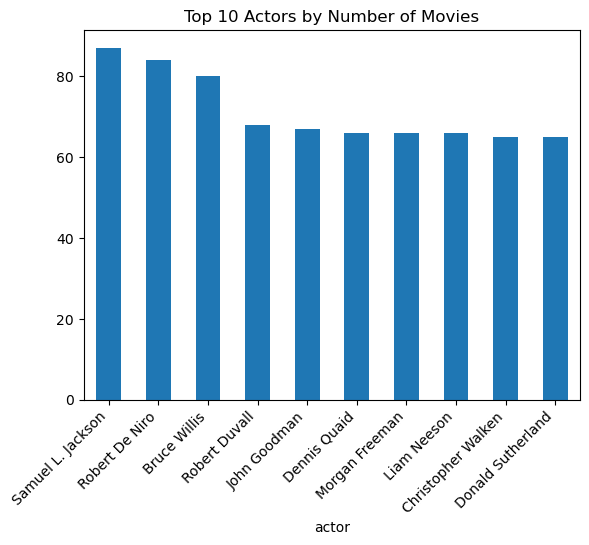

In [54]:
ax = top_actors.plot(
    x='actor',
    y='movie_count',
    kind='bar',
    legend=False,
    title='Top 10 Actors by Number of Movies'
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


8. Тепер вибери 3 найпопулярніших актори і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.
Для цього підрахуй кількість фільмів для кожного актора за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

In [56]:
##Розгортання акторів + фільтрація топ-10
actors_year_df = (
    movies_df
    .explode('cast')
    .query('cast in @top_actors_list')
)
actors_year_df

,title,year,cast,genres
5,Alex in Wonderland,1970,Donald Sutherland,"[Comedy, Drama]"
52,"Hi, Mom!",1970,Robert De Niro,[Comedy]
64,Kelly's Heroes,1970,Donald Sutherland,"[War, Action, Comedy, Drama]"
81,M*A*S*H,1970,Donald Sutherland,"[Comedy, War]"
81,M*A*S*H,1970,Robert Duvall,"[Comedy, War]"
...,...,...,...,...
11609,Joker,2019,Robert De Niro,[Thriller]
11633,Motherless Brooklyn,2019,Bruce Willis,"[Crime, Noir, War]"
11634,The Irishman,2019,Robert De Niro,[]
11642,Midway,2019,Dennis Quaid,[War]


In [58]:
##Підрахунок фільмів по роках
actor_year_counts = (
    actors_year_df
    .groupby(['year', 'cast'])
    .size()
    .reset_index(name='movie_count')
)
actor_year_counts

,year,cast,movie_count
0,1970,Donald Sutherland,4
1,1970,Robert De Niro,1
2,1970,Robert Duvall,2
3,1971,Christopher Walken,1
4,1971,Donald Sutherland,2
...,...,...,...
341,2019,John Goodman,1
342,2019,Liam Neeson,2
343,2019,Morgan Freeman,1
344,2019,Robert De Niro,2


Text(0, 0.5, 'Number of Movies')

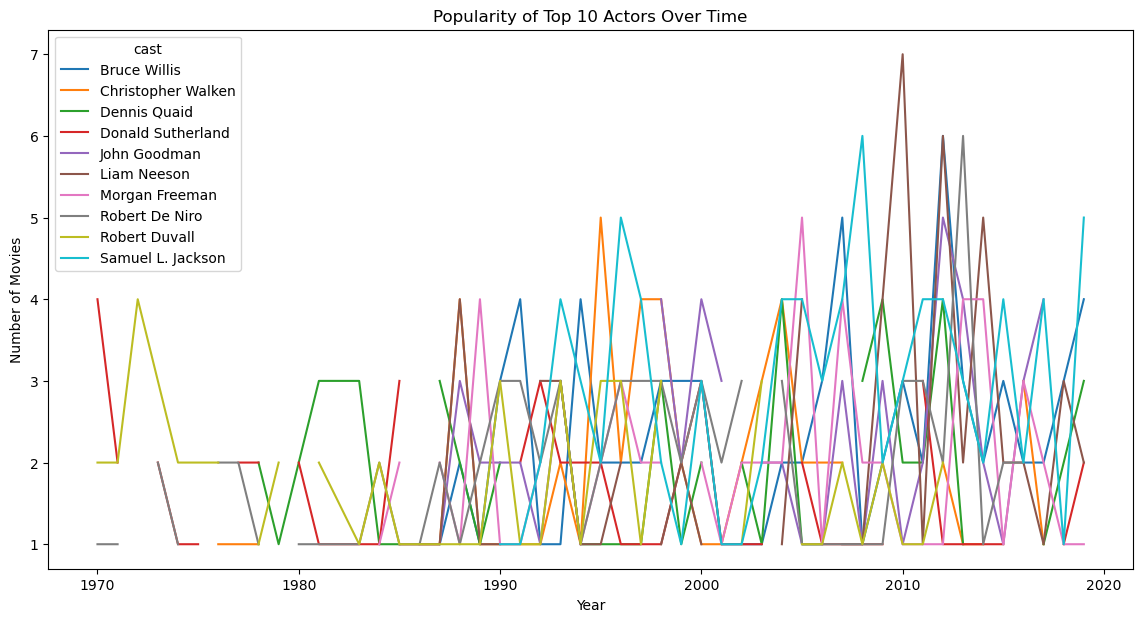

In [62]:
pivot_df = actor_year_counts.pivot(
    index='year',
    columns='cast',
    values='movie_count'
)

ax = pivot_df.plot(
    kind='line',
    figsize=(14, 7),
    title='Popularity of Top 10 Actors Over Time'
)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Movies')


***Бонусне завдання***       
Зосередься лише на 10 найпопулярніших акторах.     
 Порахуй, як часто кожен актор з'являється в фільмі, що належить до категорії топ-3 найпопулярніших жанри, та як часто в фільмі, що не включає топовий жанр.  
 Оціни пропорції для кожного актора у вигляді стовпчикової діаграми та у вигляді таблиці, де вказано також відсоток фільмів в топ жанрах.

In [45]:
##Список top-10 акторів
top_actors_list = top_actors['actor'].tolist()
top_3_genres = top_genres['genre'].head(3).tolist()
top_3_genres

['Comedy', 'Drama', 'Action']

In [46]:
##Розгортання + фільтрація ОДРАЗУ
actors_genres_df = (
    movies_df
    .explode('cast')
    .query('cast in @top_actors_list')
    .explode('genres')
)

In [43]:
##Фільтрація тільки top-10 акторів
actors_genres_df = actors_genres_df.query('cast in @top_actors_list')
actors_genres_df

,title,year,cast,genres
5,Alex in Wonderland,1970,Donald Sutherland,Comedy
5,Alex in Wonderland,1970,Donald Sutherland,Drama
52,"Hi, Mom!",1970,Robert De Niro,Comedy
64,Kelly's Heroes,1970,Donald Sutherland,War
64,Kelly's Heroes,1970,Donald Sutherland,Action
...,...,...,...,...
11633,Motherless Brooklyn,2019,Bruce Willis,War
11634,The Irishman,2019,Robert De Niro,NaN
11642,Midway,2019,Dennis Quaid,War
11663,Trauma Center,2019,Bruce Willis,Action


In [48]:
##Позначка топ-жанру
actors_genres_df['is_top_genre'] = actors_genres_df['genres'].isin(top_3_genres)
actors_genres_df


,title,year,cast,genres,is_top_genre
5,Alex in Wonderland,1970,Donald Sutherland,Comedy,True
5,Alex in Wonderland,1970,Donald Sutherland,Drama,True
52,"Hi, Mom!",1970,Robert De Niro,Comedy,True
64,Kelly's Heroes,1970,Donald Sutherland,War,False
64,Kelly's Heroes,1970,Donald Sutherland,Action,True
...,...,...,...,...,...
11633,Motherless Brooklyn,2019,Bruce Willis,War,False
11634,The Irishman,2019,Robert De Niro,NaN,False
11642,Midway,2019,Dennis Quaid,War,False
11663,Trauma Center,2019,Bruce Willis,Action,True


In [49]:
summary = (
    actors_genres_df
    .groupby(['cast', 'is_top_genre'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

summary.columns = ['actor', 'non_top_genre_movies', 'top_genre_movies']

summary['total'] = summary['top_genre_movies'] + summary['non_top_genre_movies']
summary['top_genre_percent'] = (summary['top_genre_movies'] / summary['total'] * 100).round(2)

summary


,actor,non_top_genre_movies,top_genre_movies,total,top_genre_percent
0,Bruce Willis,90,85,175,48.57
1,Christopher Walken,72,63,135,46.67
2,Dennis Quaid,90,66,156,42.31
3,Donald Sutherland,71,56,127,44.09
4,John Goodman,77,69,146,47.26
5,Liam Neeson,84,57,141,40.43
6,Morgan Freeman,74,55,129,42.64
7,Robert De Niro,93,82,175,46.86
8,Robert Duvall,69,61,130,46.92
9,Samuel L. Jackson,101,61,162,37.65


In [51]:
summary.index = range(1, len(summary) + 1)
summary.index.name = 'rank'
summary



,actor,non_top_genre_movies,top_genre_movies,total,top_genre_percent
rank,,,,,
1,Bruce Willis,90,85,175,48.57
2,Christopher Walken,72,63,135,46.67
3,Dennis Quaid,90,66,156,42.31
4,Donald Sutherland,71,56,127,44.09
5,John Goodman,77,69,146,47.26
6,Liam Neeson,84,57,141,40.43
7,Morgan Freeman,74,55,129,42.64
8,Robert De Niro,93,82,175,46.86
9,Robert Duvall,69,61,130,46.92


[Text(0, 0, 'Bruce Willis'),
 Text(1, 0, 'Christopher Walken'),
 Text(2, 0, 'Dennis Quaid'),
 Text(3, 0, 'Donald Sutherland'),
 Text(4, 0, 'John Goodman'),
 Text(5, 0, 'Liam Neeson'),
 Text(6, 0, 'Morgan Freeman'),
 Text(7, 0, 'Robert De Niro'),
 Text(8, 0, 'Robert Duvall'),
 Text(9, 0, 'Samuel L. Jackson')]

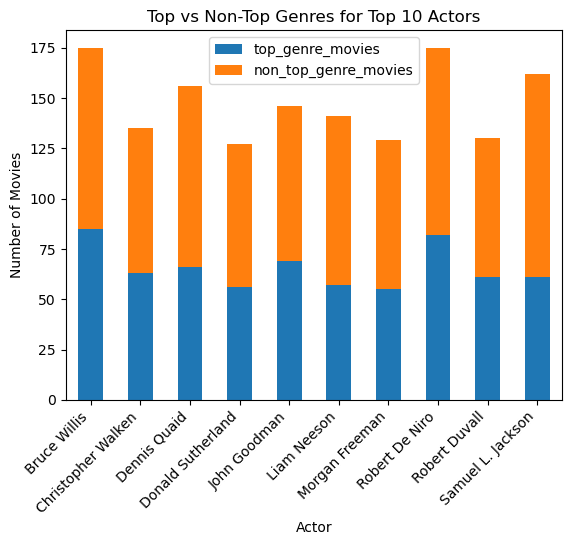

In [52]:
ax = summary.plot(
    x='actor',
    y=['top_genre_movies', 'non_top_genre_movies'],
    kind='bar',
    stacked=True,
    title='Top vs Non-Top Genres for Top 10 Actors'
)

ax.set_ylabel('Number of Movies')
ax.set_xlabel('Actor')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
